**Project TEAMID** - PTID-CDS-JUL-26-11218

**Project CODE** - PRCP-1016-HeartDiseasePrediction

**Project Name** - Heart Disease Prediction

**Project Type** - Supervised Machine Learning Classification Project

**Contribution** - Individual

## Project Objective
This notebook is prepared directly from the supplied PRCP-1016 problem statement.

**Task 1:** Prepare a complete data analysis report.  
**Task 2:** Build machine-learning models to predict potential heart disease.  
**Task 3:** Provide hospital-oriented suggestions to support early detection and reduce life-threatening risk.

### Dataset structure from the problem statement
The supplied specification describes **14 columns**: `patient_id` plus 13 patient/examination features. The target is supplied separately as `heart_disease_present`.



## 1. Dataset and Feature Dictionary

The project specification describes these fields:

| Feature | Type / meaning |
|---|---|
| `patient_id` | Unique/random patient identifier; excluded from modeling |
| `slope_of_peak_exercise_st_segment` | Slope of peak exercise ST segment |
| `thal` | Thallium stress-test result: normal / fixed_defect / reversible_defect |
| `resting_blood_pressure` | Resting blood pressure |
| `chest_pain_type` | Chest-pain category |
| `num_major_vessels` | Number of major vessels colored by fluoroscopy (0–3) |
| `fasting_blood_sugar_gt_120_mg_per_dl` | Fasting blood sugar >120 mg/dl |
| `resting_ekg_results` | Resting ECG result |
| `serum_cholesterol_mg_per_dl` | Serum cholesterol |
| `oldpeak_eq_st_depression` | Exercise-induced ST depression |
| `sex` | 0=female, 1=male |
| `age` | Age in years |
| `max_heart_rate_achieved` | Maximum heart rate achieved |
| `exercise_induced_angina` | 0=False, 1=True |
| `heart_disease_present` | Target: 0/1 |


## Import Labraries and Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
     accuracy_score, precision_score, recall_score, f1_score,
     roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


In [2]:
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Load and Prepare the Supplied Dataset

The PRCP-1016 project commonly provides two files:

- `values.csv` — patient features
- `labels.csv` — `heart_disease_present` target


In [3]:
import os

VALUES_PATH = "values.csv"
LABELS_PATH = "labels.csv"
SINGLE_DATASET_PATH = "heart_disease.csv"

if os.path.exists(VALUES_PATH) and os.path.exists(LABELS_PATH):
    values = pd.read_csv(VALUES_PATH)
    labels = pd.read_csv(LABELS_PATH)

    print("Values Shape: ", values.shape)
    print("labels Shape: ", labels.shape)

    if "patient_id" in values.columns and "patient_id" in labels.columns:
        df = values.merge(labels, on = "patient_id", how="inner", validate="one_to_one")
    else:
        raise ValueError("Both values.csv and labels.csv must contain patient_id.")
elif os.path.exists(SINGLE_DATASET_PATH):
    df = pd.read_csv(SINGLE_DATASET_PATH)
else:
    raise FileNotFoundError(
        "Dataset file not found."
    )
print("Merged dataset shape: ", df.shape)
display(df.head())

Values Shape:  (180, 14)
labels Shape:  (180, 2)
Merged dataset shape:  (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


## Basic Checks

In [4]:
print("Number of Rows and columns: ", df.shape)

Number of Rows and columns:  (180, 15)


In [5]:
print("Column Names: ")
print(df.columns.tolist())

Column Names: 
['patient_id', 'slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age', 'max_heart_rate_achieved', 'exercise_induced_angina', 'heart_disease_present']


In [6]:
print("Data types: ")
print(df.dtypes.to_frame("dtype"))

Data types: 
                                        dtype
patient_id                             object
slope_of_peak_exercise_st_segment       int64
thal                                   object
resting_blood_pressure                  int64
chest_pain_type                         int64
num_major_vessels                       int64
fasting_blood_sugar_gt_120_mg_per_dl    int64
resting_ekg_results                     int64
serum_cholesterol_mg_per_dl             int64
oldpeak_eq_st_depression              float64
sex                                     int64
age                                     int64
max_heart_rate_achieved                 int64
exercise_induced_angina                 int64
heart_disease_present                   int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [8]:
print("Statistical Summary: ")
print(df.describe())

Statistical Summary: 
       slope_of_peak_exercise_st_segment  resting_blood_pressure  \
count                         180.000000              180.000000   
mean                            1.550000              131.311111   
std                             0.618838               17.010443   
min                             1.000000               94.000000   
25%                             1.000000              120.000000   
50%                             1.000000              130.000000   
75%                             2.000000              140.000000   
max                             3.000000              180.000000   

       chest_pain_type  num_major_vessels  \
count       180.000000         180.000000   
mean          3.155556           0.694444   
std           0.938454           0.969347   
min           1.000000           0.000000   
25%           3.000000           0.000000   
50%           3.000000           0.000000   
75%           4.000000           1.000000   
max  

In [9]:
print("Missing Values: ")
print(df.isnull().sum().sort_values(ascending=False).to_frame("Missing"))

Missing Values: 
                                      Missing
patient_id                                  0
slope_of_peak_exercise_st_segment           0
thal                                        0
resting_blood_pressure                      0
chest_pain_type                             0
num_major_vessels                           0
fasting_blood_sugar_gt_120_mg_per_dl        0
resting_ekg_results                         0
serum_cholesterol_mg_per_dl                 0
oldpeak_eq_st_depression                    0
sex                                         0
age                                         0
max_heart_rate_achieved                     0
exercise_induced_angina                     0
heart_disease_present                       0


In [10]:
print("Duplicate Rows: ", df.duplicated().sum())

Duplicate Rows:  0


## Target Distribution

heart_disease_present
0    100
1     80
Name: count, dtype: int64
heart_disease_present
0    55.56
1    44.44
Name: proportion, dtype: float64


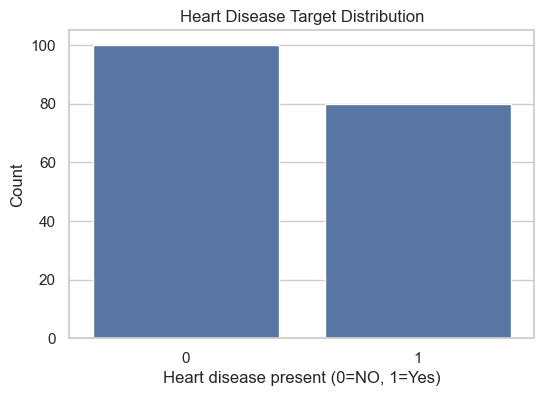

In [11]:
if "heart_disease_present" not in df.columns:
    raise ValueError("Target column 'heart_disease_present' is missing.")

print(df["heart_disease_present"].value_counts())
print(df["heart_disease_present"].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="heart_disease_present")
plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart disease present (0=NO, 1=Yes)")
plt.ylabel("Count")
plt.show()

# 3. Data Cleaning

In [12]:
binary_cols = [
    "fasting_blood_sugar_gt_120_mg_per_dl",
    "sex",
    "exercise_include_angina"
]

for col  in binary_cols:
    if col in df.columns:
        print(f"{col}: {sorted(df[col].dropna().unique())}")

print("\n Target values: ", sorted(df["heart_disease_present"].dropna().unique()))

fasting_blood_sugar_gt_120_mg_per_dl: [np.int64(0), np.int64(1)]
sex: [np.int64(0), np.int64(1)]

 Target values:  [np.int64(0), np.int64(1)]


In [13]:
# Remove exact duplicates only where present
before = len(df)
df = df.drop_duplicates().copy()
print(f"Remove {before-len(df)} exact duplicate rows.")


Remove 0 exact duplicate rows.


In [14]:
df["heart_disease_present"] = pd.to_numeric(
    df["heart_disease_present"], errors = "coerce"
)

df = df[df["heart_disease_present"].isin([0,1])].copy()
df["heart_disease_present"] = df["heart_disease_present"].astype(int)

print("Cleaned Shape: ", df.shape)

Cleaned Shape:  (180, 15)


## 4. Exploratory Data Analysis (EDA)

The analysis includes:

    1. Univariate Distributions
    2. Categorical Feature Frequence
    3. Numeric Features vs Target
    4. Correlation Analysis
    5. Outlier inspection
    6. Class-balance Assessment


In [15]:
target = "heart_disease_present"
id_col = "patient_id"

categorical_features = [
    "slope_of_peak_exercise_st_segment",
    "thal",
    "chest_pain_type",
    "num_major_vessels",
    "fasting_blood_sugar_gt_120_mg_per_dl",
    "resting_ekg_results",
    "sex",
    "exercise_induced_angina"
]

numeric_features = [
    "resting_blood_pressure",
    "serum_cholesterol_mg_per_dl",
    "oldpeak_eq_st_depression",
    "age",
    "max_heart_rate_achieved"
]

categorical_features = [c for c in categorical_features if c in df.columns]
numeric_features = [c for c in numeric_features if c in df.columns]

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)

Categorical: ['slope_of_peak_exercise_st_segment', 'thal', 'chest_pain_type', 'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'sex', 'exercise_induced_angina']
Numeric: ['resting_blood_pressure', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'age', 'max_heart_rate_achieved']


,count,mean,std,min,25%,50%,75%,max
resting_blood_pressure,180.0,131.311111,17.010443,94.0,120.00,130.0,140.00,180.0
serum_cholesterol_mg_per_dl,180.0,249.211111,52.717969,126.0,213.75,245.5,281.25,564.0
oldpeak_eq_st_depression,180.0,1.010000,1.121357,0.0,0.00,0.8,1.60,6.2
age,180.0,54.811111,9.334737,29.0,48.00,55.0,62.00,77.0
max_heart_rate_achieved,180.0,149.483333,22.063513,96.0,132.00,152.0,166.25,202.0


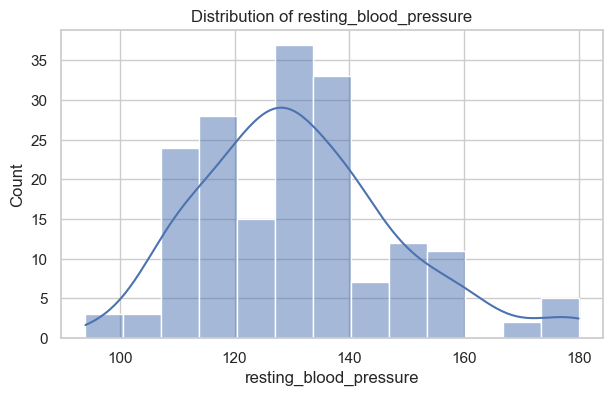

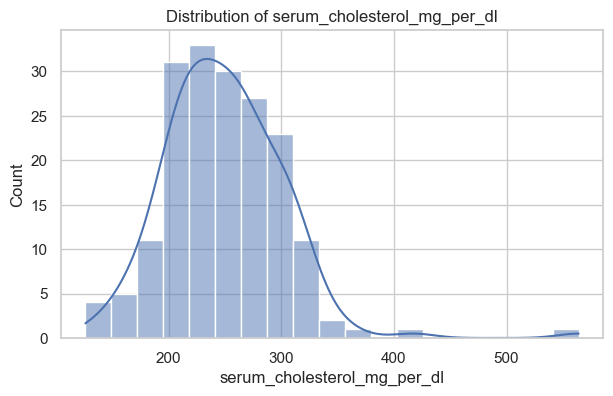

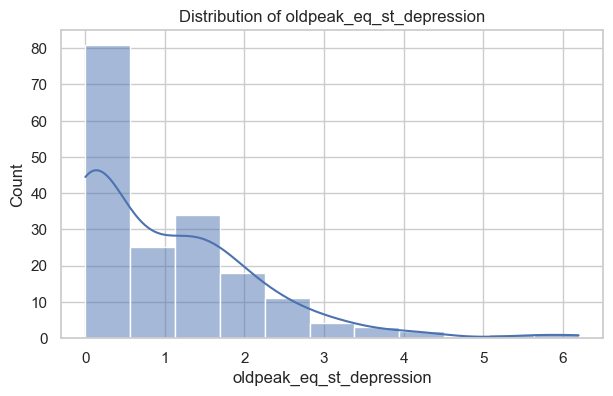

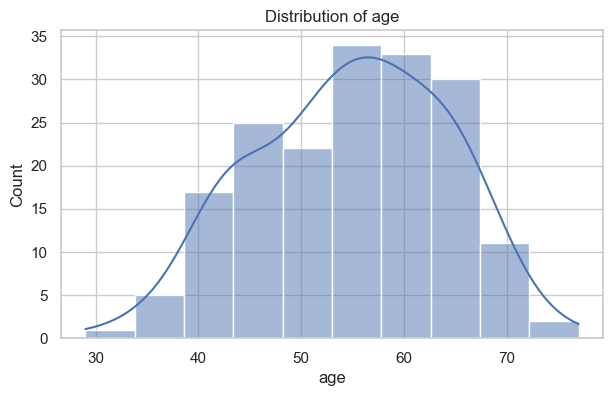

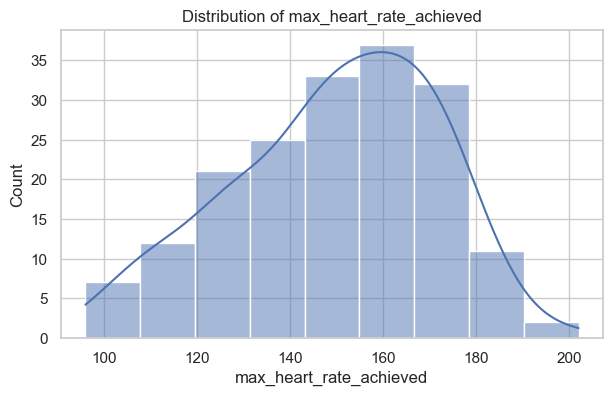

In [16]:
# Numeric summary
display(df[numeric_features].describe().T)

# Histograms
for col in numeric_features:
    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


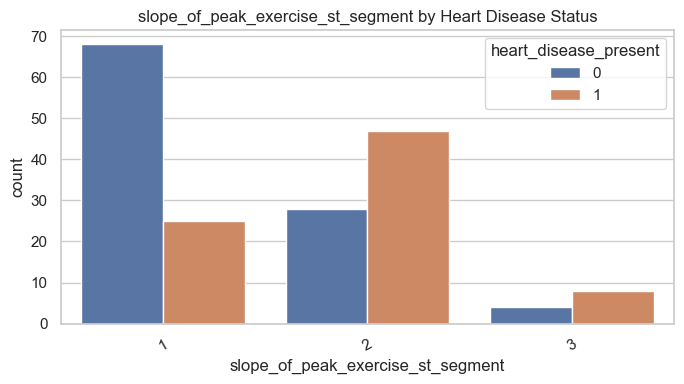

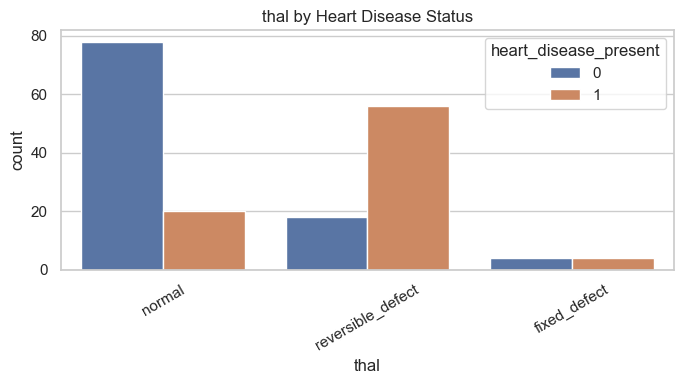

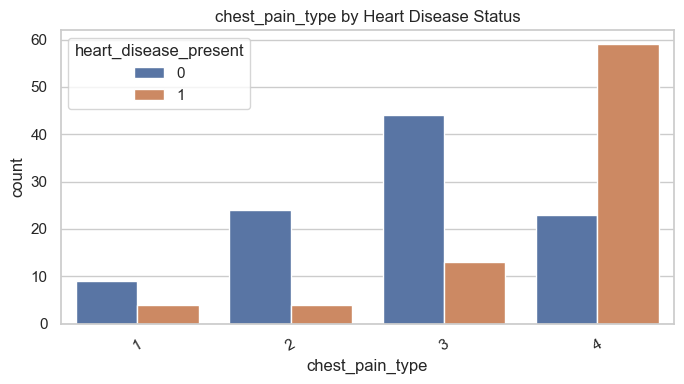

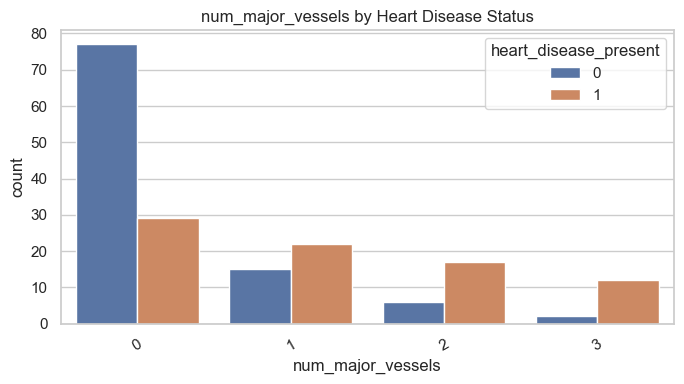

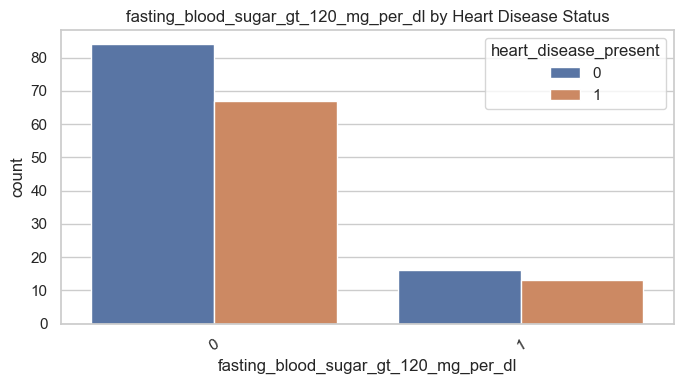

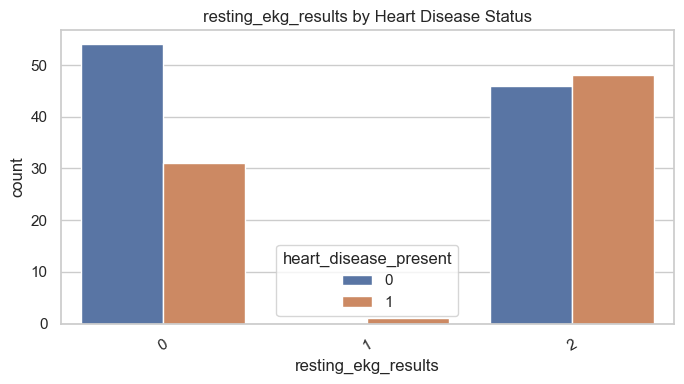

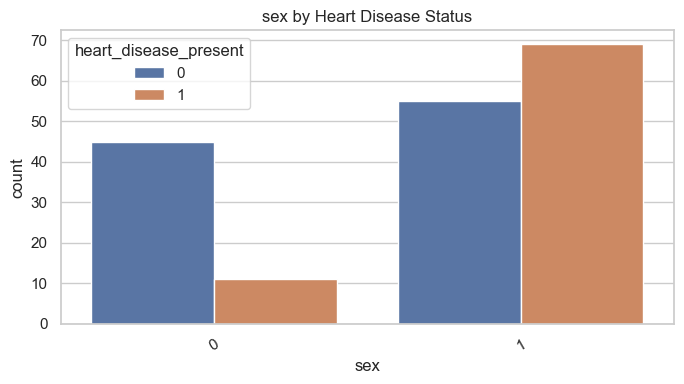

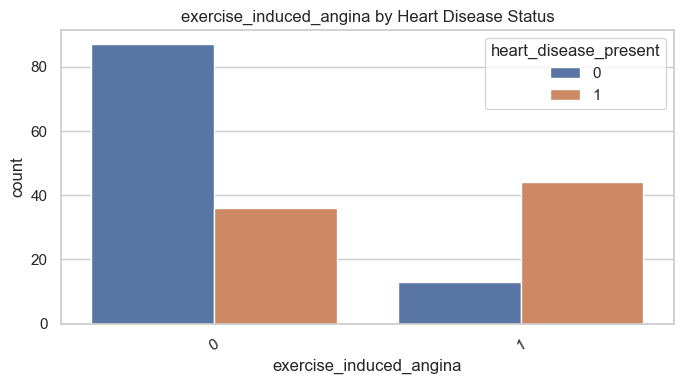

In [17]:
# Categorical distributions
for col in categorical_features:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col, hue=target)
    plt.title(f"{col} by Heart Disease Status")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


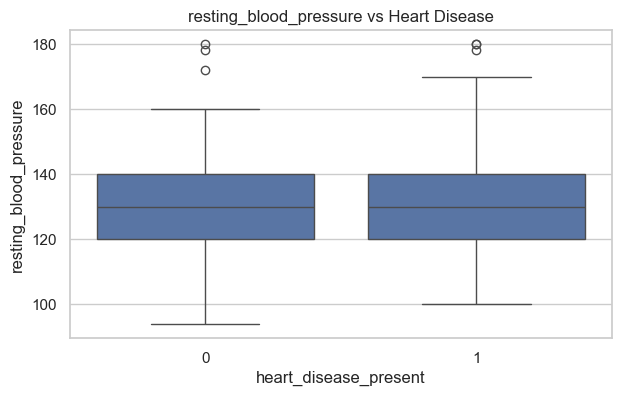

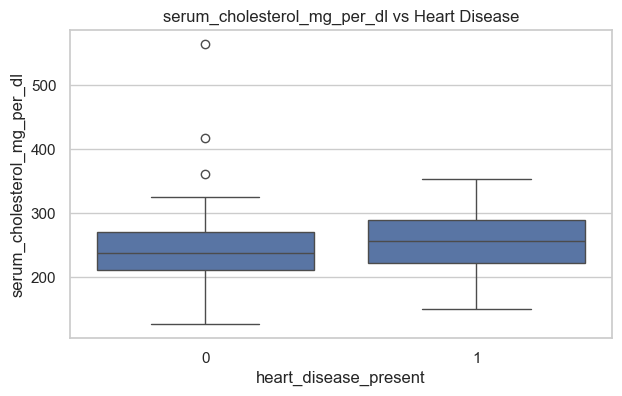

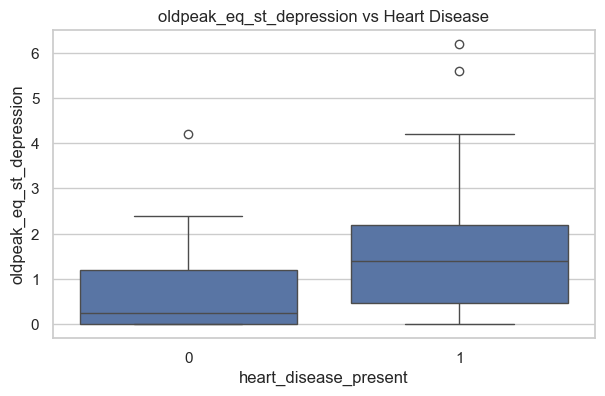

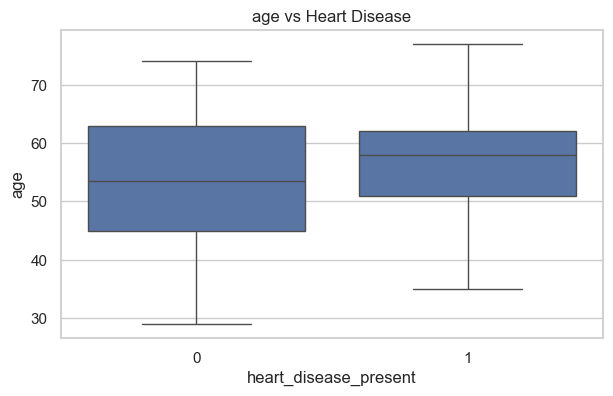

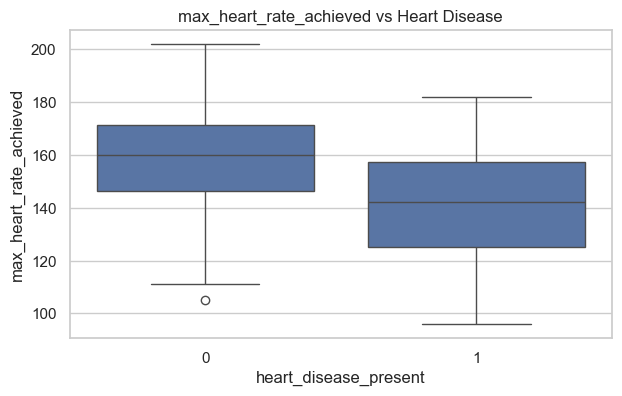

In [18]:
# Numeric features vs target
for col in numeric_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x=target, y=col)
    plt.title(f"{col} vs Heart Disease")
    plt.show()


## Correlation 

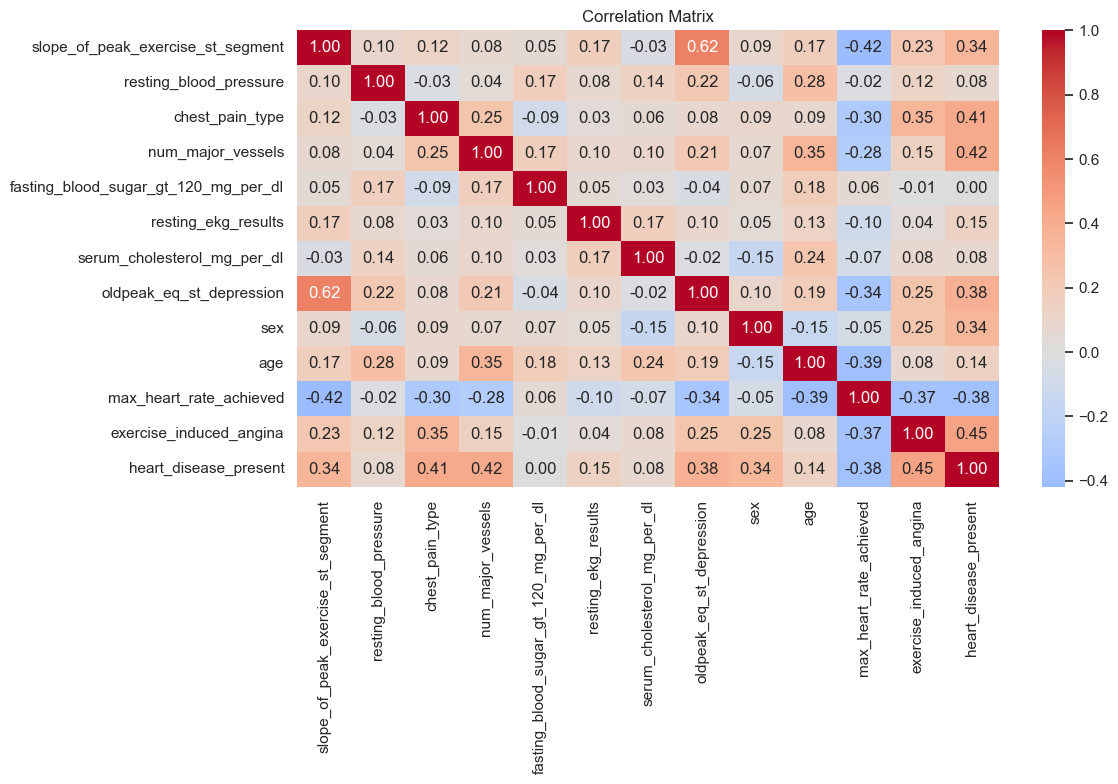

In [19]:
numeric_corr = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [20]:
def iqr_outlier_report(data, columns):
    rows = []
    for col in columns:
        s = data[col].dropna()
        Q1, Q3 = s.quantile([0.25, 0.75])
        IQR = Q3 -Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        count = ((s < lower) | (s > upper)).sum()
        rows.append([col, Q1, Q3, IQR, lower, upper, int(count)])
    return pd.DataFrame(
        rows,
        columns = ["feature", "Q1", "Q3", "IQR", "lower_bound", "upper_bound", "outlier_count"]
    )

outlier_report = iqr_outlier_report(df, numeric_features)
display(outlier_report)
        

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,resting_blood_pressure,120.00,140.00,20.00,90.000,170.000,6
1,serum_cholesterol_mg_per_dl,213.75,281.25,67.50,112.500,382.500,2
2,oldpeak_eq_st_depression,0.00,1.60,1.60,-2.400,4.000,4
3,age,48.00,62.00,14.00,27.000,83.000,0
4,max_heart_rate_achieved,132.00,166.25,34.25,80.625,217.625,0


## 5. Feature Engineering and Preprocessing

patient_id is an identifier and is excluded from prediction.

For the coded categorical variables, one-hot encoding is used so the models do not incorrectly assume that category codes represnt continuous measurements. Numeric variables are standardized for scale-sensitive algorithms.

Missing values are handled inside the preprocessing pipeline to prevent data leakage.

In [21]:
x = df.drop(columns = [target, id_col], errors = 'ignore')
y = df[target]

In [22]:
categorical_features =[c for c in categorical_features if c in x.columns]
numeric_features = [c for c in numeric_features if c in x.columns]

In [23]:
numeric_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())    
])

categorical_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown = "ignore"))
])

preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, stratify = y, random_state = RANDOM_STATE)

In [25]:
print("Train Shape:  ", x_train.shape)
print("Test Shape: ", x_test.shape)

Train Shape:   (144, 13)
Test Shape:  (36, 13)


## 6. Multiple Machine-Learning Models

The comparison includes:
- Logistic Regression
- K-Nearest Neighbors
- Support Vector Machine
- Decision Tree
- Random Forest
- Gradient Boosting

For a healthcare screening problem, **recall/sensitivity is especially important**, because a false negative can mean a potentially high-risk patient is missed. Accuracy alone is therefore not used to choose the production candidate. 

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter = 2000, random_state = RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability = True, random_state = RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state = RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators = 300,
        random_state = RANDOM_STATE,
        class_weight = "balanced"
    ),
    "GBC": GradientBoostingClassifier(random_state = RANDOM_STATE) 

}

pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state =RANDOM_STATE)

cv_results = []
for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe, x_train, y_train,
        cv = cv,
        scoring = scoring,
        n_jobs = -1
    )
    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    ["CV Recall", "CV ROC-AUC"], ascending = False
).reset_index(drop = True)

display(cv_results_df.round(4))

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,GBC,0.7911,0.7635,0.7974,0.7745,0.8639
1,SVM,0.8126,0.8108,0.7821,0.7873,0.8642
2,Decision Tree,0.7424,0.6880,0.7641,0.7224,0.7446
3,Random Forest,0.7781,0.7715,0.7513,0.7532,0.8654
4,Logistic Regression,0.7921,0.8118,0.7346,0.7597,0.8640
5,KNN,0.7845,0.7833,0.7346,0.7497,0.8319


In [27]:
test_results = []
fitted_models = {}

for name, pipe in pipelines.items():
    pipe.fit(x_train, y_train)
    fitted_models[name] = pipe

    pred = pipe.predict(x_test)
    proba = pipe.predict_proba(x_test)[:, 1]

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division = 0),
        "Recall": recall_score(y_test, pred, zero_division = 0),
        "F1": f1_score(y_test, pred, zero_division = 0),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })

test_results_df = pd.DataFrame(test_results).sort_values(
    ["Recall", "ROC-AUC"], ascending = False
).reset_index(drop = True)

display(test_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM,0.9167,0.8421,1.0000,0.9143,0.9625
1,Logistic Regression,0.8889,0.8000,1.0000,0.8889,0.9562
2,GBC,0.8889,0.8000,1.0000,0.8889,0.9469
3,Random Forest,0.8611,0.7895,0.9375,0.8571,0.9406
4,KNN,0.8611,0.7895,0.9375,0.8571,0.9344
5,Decision Tree,0.7778,0.7857,0.6875,0.7333,0.7687


### Visual model comparison

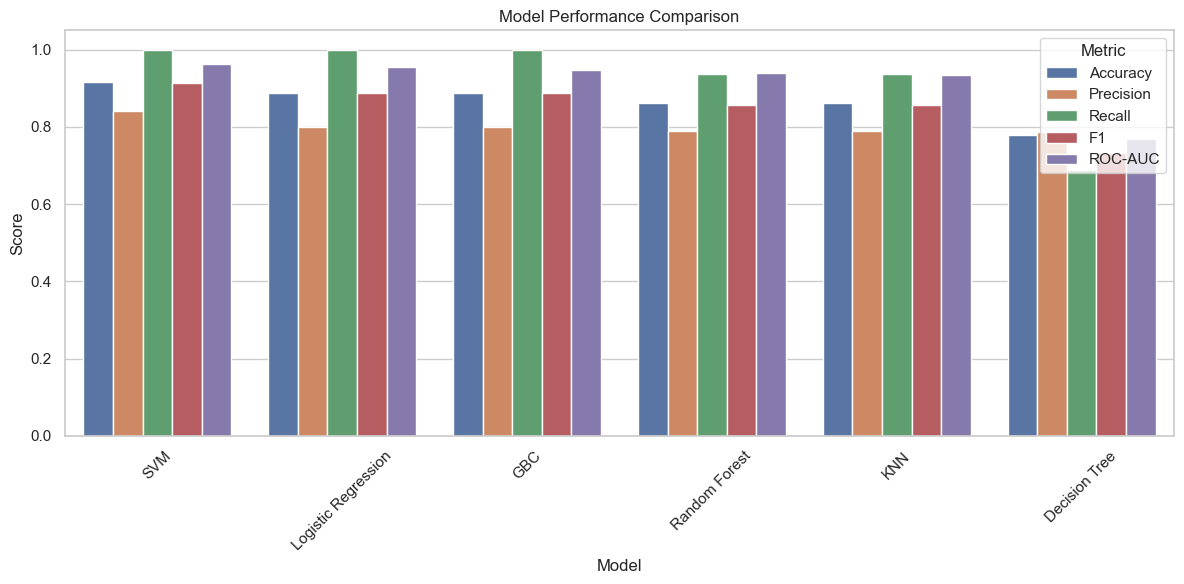

In [28]:
plot_df = test_results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 7. Confusion Matrix And ROC Analysis

The confusion matrix make  false negative visible. ROC-AUC provides a thresold-independent ranking metric, while recall shows how many actual positive cases are detected.


Logistic Regression
                  precision    recall  f1-score   support

No Heart Disease       1.00      0.80      0.89        20
   Heart Disease       0.80      1.00      0.89        16

        accuracy                           0.89        36
       macro avg       0.90      0.90      0.89        36
    weighted avg       0.91      0.89      0.89        36



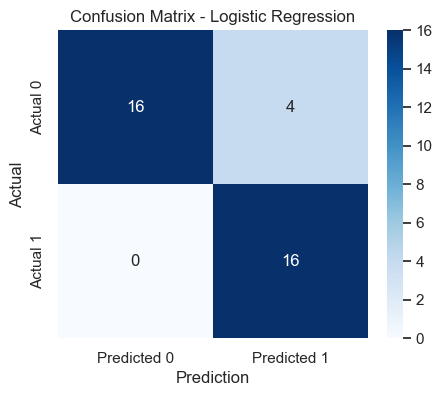


KNN
                  precision    recall  f1-score   support

No Heart Disease       0.94      0.80      0.86        20
   Heart Disease       0.79      0.94      0.86        16

        accuracy                           0.86        36
       macro avg       0.87      0.87      0.86        36
    weighted avg       0.87      0.86      0.86        36



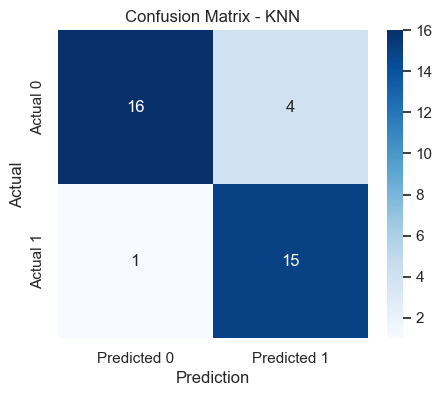


SVM
                  precision    recall  f1-score   support

No Heart Disease       1.00      0.85      0.92        20
   Heart Disease       0.84      1.00      0.91        16

        accuracy                           0.92        36
       macro avg       0.92      0.93      0.92        36
    weighted avg       0.93      0.92      0.92        36



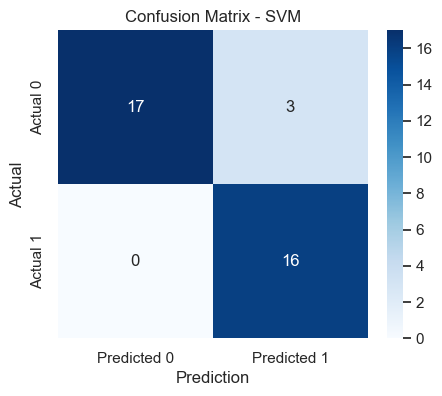


Decision Tree
                  precision    recall  f1-score   support

No Heart Disease       0.77      0.85      0.81        20
   Heart Disease       0.79      0.69      0.73        16

        accuracy                           0.78        36
       macro avg       0.78      0.77      0.77        36
    weighted avg       0.78      0.78      0.78        36



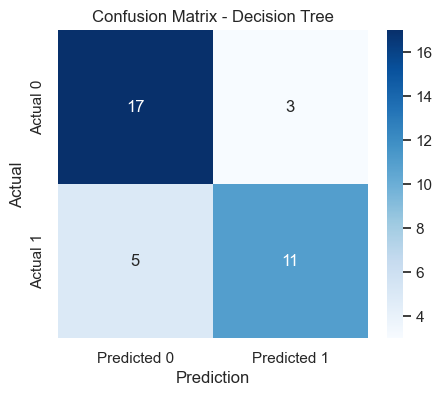


Random Forest
                  precision    recall  f1-score   support

No Heart Disease       0.94      0.80      0.86        20
   Heart Disease       0.79      0.94      0.86        16

        accuracy                           0.86        36
       macro avg       0.87      0.87      0.86        36
    weighted avg       0.87      0.86      0.86        36



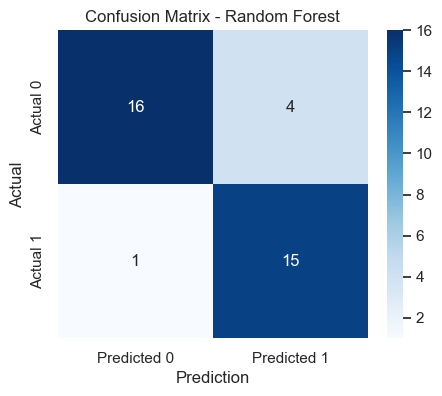


GBC
                  precision    recall  f1-score   support

No Heart Disease       1.00      0.80      0.89        20
   Heart Disease       0.80      1.00      0.89        16

        accuracy                           0.89        36
       macro avg       0.90      0.90      0.89        36
    weighted avg       0.91      0.89      0.89        36



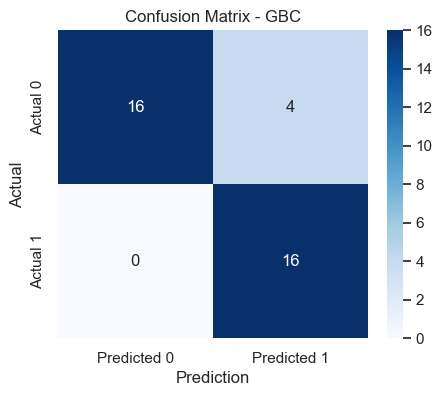

In [29]:
# Detailed evaluation for every model.

for name, pipe in fitted_models.items():
    pred = pipe.predict(x_test)
    proba = pipe.predict_proba(x_test)[:, 1]

    print("\n" + "="*70)
    print(name)
    print("="*70)
    print(classification_report(
        y_test, pred,
        target_names = ["No Heart Disease", "Heart Disease"],
        zero_division = 0
    ))

    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize = (5,4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels = ["Predicted 0", "Predicted 1"],
        yticklabels = ["Actual 0", "Actual 1"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Prediction")
    plt.ylabel("Actual")
    plt.show() 

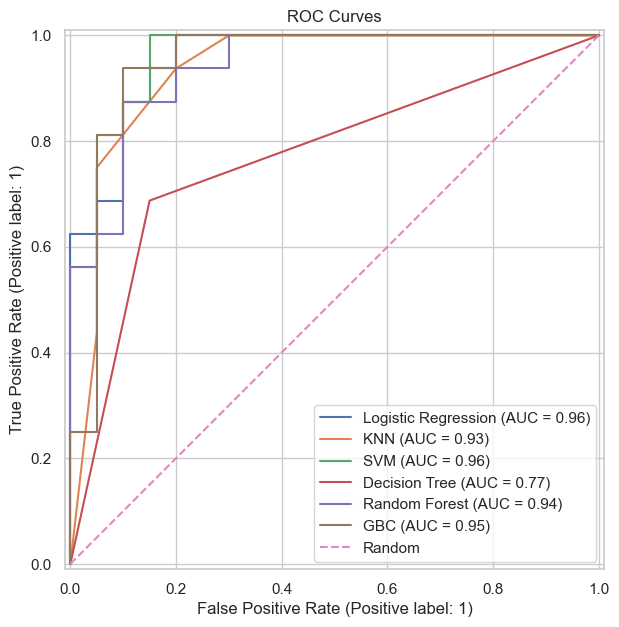

In [30]:
# ROC Curves
plt.figure(figsize = (9,7))
for name, pipe in fitted_models.items():
    RocCurveDisplay.from_estimator(pipe, x_test, y_test, name=name, ax = plt.gca())

plt.plot([0,1], [0,1], linestyle = "--", label="Random")
plt.title("ROC Curves")
plt.legend()
plt.show()

## Hyperparameter Tuning

The top models are tuned using cross-validated grid search. The ranking emphasize recall first and ROC-AUC second because the project is a disease-screening task.

In [31]:
# Tune selected candidate models
candidate_names = test_results_df.head(3)["Model"].tolist()
candidate_names

['SVM', 'Logistic Regression', 'GBC']

In [32]:
# Parameter grids

param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__class_weight": [None, "distance"]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weight": ["uniform", "distance"]
    },

    "SVM":{
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__class_weight": [None, "balanced"]  
    },

    "Decision Tree":{
        "model__max_depth": [None, 3, 5, 7, 10],
        "model__min_samples_split": [2, 5, 10],
        "model__class_weight": [None, "Balanced"]
    },

    "Random Forest":{
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5],
        "model__class_weight": [None, "balanced"]
        
    },

    "GBC":{
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3]
    }
}

tuned_models = {}
tuning_rows = []

for name in candidate_names:
    grid = GridSearchCV(
        estimator = pipelines[name],
        param_grid = param_grids[name],
        scoring = 'recall',
        cv = cv,
        n_jobs = -1,
        refit = True
    )

    grid.fit(x_train, y_train)
    tuned_models[name] = grid.best_estimator_

    pred = grid.best_estimator_.predict(x_test)
    proba = grid.best_estimator_.predict_proba(x_test)[:, 1]

    tuning_rows.append({
        "Model": name,
        "Best CV Recall": grid.best_score_,
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test Precision": precision_score(y_test, pred, zero_division=0),
        "Test Recall": recall_score(y_test, pred, zero_division = 0),
        "Test F1": f1_score(y_test, pred, zero_division = 0),
        "Test ROC-AUC": roc_auc_score(y_test, proba),
        "Best Parameters": grid.best_params_
    })

tuned_results_df = pd.DataFrame(tuning_rows).sort_values(
    ["Test Recall", "Test ROC-AUC"], ascending=False
).reset_index(drop=True)

display(tuned_results_df.round(4))


,Model,Best CV Recall,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Best Parameters
0,SVM,0.7821,0.9167,0.8421,1.0000,0.9143,0.9625,"{'model__C': 1, 'model__class_weight': None, '..."
1,GBC,0.8141,0.8889,0.8000,1.0000,0.8889,0.9594,"{'model__learning_rate': 0.05, 'model__max_dep..."
2,Logistic Regression,0.7641,0.8889,0.8333,0.9375,0.8824,0.9500,"{'model__C': 0.1, 'model__class_weight': None}"


## 9. Select the Production Candidate

The following rule is intentionally explicit:

1. Prefer the model with the highest test recall among tuned candidates.
2. Use ROC_AUC as a tie-breaker.
3. Inspect precision/F1 and the confusion matrix before deployment.
4. Do not treat the model as a standalone medical diagnosis.

In [33]:
# Atomatic Production condidate selection

best_model_name = tuned_results_df.iloc[0]["Model"]
best_model = tuned_models[best_model_name]

best_pred = best_model.predict(x_test)
best_proba = best_model.predict_proba(x_test)[:, 1]

print("Recommended production candidate: ", best_model_name)
print("Recall: ", round(recall_score(y_test, best_pred), 4))
print("Precision: ", round(precision_score(y_test, best_pred, zero_division=0), 4))
print("F1: ", round(f1_score(y_test, best_pred, zero_division=0), 4))
print("ROC-AUC: ", round(roc_auc_score(y_test, best_proba), 4))

print("\n Confusion Matrix: ")
print(confusion_matrix(y_test, best_pred))

Recommended production candidate:  SVM
Recall:  1.0
Precision:  0.8421
F1:  0.9143
ROC-AUC:  0.9625

 Confusion Matrix: 
[[17  3]
 [ 0 16]]


## 10. Feature Importance / Model Explainability

For tree-based models, feature importance can be inspected after preprocessing. The code below retrives transformation feature names when supported.

For a clinical application, explainability should be reviewed alongside calibration, subgroup performance, false-negative analysis, and clinical validation.

In [34]:
if hasattr(best_model.named_steps["model"], "feature_importances_"):
    prep = best_model.named_steps["preprocessor"]
    model = best_model.named_steps["model"]

    try:
        feature_names = prep.get_feature_names_out()
        importance = pd.series(
            model.feature_importances_,
            index = feature_names
        ).sort_values(ascending = False).head(20)

        plt.figure(figsize = (10, 7))
        importance.sort_values().plot(kind = "barh")
        plt.title(f"Top Feature Importances - {best_model_name}")
        plt.xlabel("Importance")
        plt.show()

        display(importance.to_frame("importance"))
    except Exception as e:
        print("Feature-name extraction was not available: ", e)
else:
    print(
        f"{best_model_name} does not expose tree-style feature_importances_. "
         "Use model coefficients or permutation importance for explainability."
    )

SVM does not expose tree-style feature_importances_. Use model coefficients or permutation importance for explainability.


## 11. Example Prediction Function

In [35]:
# 23. Prediction function
def predict_heart_disease(
    slope_of_peak_exercise_st_segment,
    thal,
    resting_blood_pressure,
    chest_pain_type,
    num_major_vessels,
    fasting_blood_sugar_gt_120_mg_per_dl,
    resting_ekg_results,
    serum_cholesterol_mg_per_dl,
    oldpeak_eq_st_depression,
    sex,
    age,
    max_heart_rate_achieved,
    exercise_induced_angina
):
    sample = pd.DataFrame([{
        "slope_of_peak_exercise_st_segment": slope_of_peak_exercise_st_segment,
        "thal": thal,
        "resting_blood_pressure": resting_blood_pressure,
        "chest_pain_type": chest_pain_type,
        "num_major_vessels": num_major_vessels,
        "fasting_blood_sugar_gt_120_mg_per_dl": fasting_blood_sugar_gt_120_mg_per_dl,
        "resting_ekg_results": resting_ekg_results,
        "serum_cholesterol_mg_per_dl": serum_cholesterol_mg_per_dl,
        "oldpeak_eq_st_depression": oldpeak_eq_st_depression,
        "sex": sex,
        "age": age,
        "max_heart_rate_achieved": max_heart_rate_achieved,
        "exercise_induced_angina": exercise_induced_angina
    }])

    probability = float(best_model.predict_proba(sample)[:, 1][0])
    prediction = int(probability >= 0.5)

    return {
        "predicted_class": prediction,
        "heart_disease_probability": round(probability, 4),
        "interpretation": (
            "Higher predicted risk — clinical review recommended."
            if prediction == 1
            else "Lower predicted risk according to this model."
        )
    }


## 12. Hospital Recommendations — Task 3

Based on the project objective, the hospital can use the model as an **early-warning and triage-support tool**, not as a replacement for clinical diagnosis.

### Recommended actions
1. **Early screening:** Flag higher-risk records for timely clinical review.
2. **Prioritize recall:** Monitor false negatives because missed high-risk cases can be more consequential than unnecessary follow-up.
3. **Clinical validation:** Validate the model prospectively with hospital data before operational use.
4. **Human-in-the-loop review:** Require clinician assessment before treatment or diagnostic decisions.
5. **Regular monitoring:** Track recall, precision, calibration, drift, and false-negative rates after deployment.
6. **Data quality controls:** Standardize how blood pressure, cholesterol, ECG-related values, thallium results, and coded categories are entered.
7. **Patient follow-up:** Use risk flags to support appropriate follow-up, preventive counseling, and further diagnostic evaluation.
8. **Privacy and governance:** Protect patient identifiers and restrict model outputs to authorized healthcare workflows.
9. **Subgroup checks:** Evaluate performance across relevant patient groups to identify unequal error rates.
10. **Threshold review:** The 0.50 classification threshold should not automatically be treated as the clinical threshold; it should be selected using validation data and clinical costs of false positives/negatives.


## 13. Challenges Faced and Techniques Used

| Challenge | Technique | Reason |
|---|---|---|
| Separate feature and label files | Merge on `patient_id` | Reconstruct the modeling table correctly |
| Identifier column | Exclude `patient_id` | Prevent the random identifier from influencing prediction |
| Missing values | Median/mode imputation in pipeline | Keeps preprocessing reproducible and avoids leakage |
| Coded categorical variables | One-hot encoding | Avoids treating category codes as continuous distances |
| Different numeric scales | StandardScaler | Helps Logistic Regression, KNN and SVM |
| Potential outliers | IQR reporting; no automatic deletion | Extreme clinical values may be legitimate |
| Class imbalance | Stratified split + class weights where supported | Preserves class proportions and can reduce missed positives |
| Model comparison | CV + held-out test metrics | More reliable comparison than training accuracy |
| Healthcare error costs | Emphasis on recall | Reduces the chance of missing positive cases |
| Hyperparameter selection | GridSearchCV | Finds better model settings using cross-validation |
| Data leakage risk | Fit preprocessing only inside Pipeline | Ensures transformations use training data only |


## Final Model Comparision Report

In [36]:
# 24. Final report
print("="*80)
print("PRCP-1016 HEART DISEASE PREDICTION — FINAL MODEL REPORT")
print("="*80)

print("\nDataset shape:", df.shape)
print("Training rows:", len(x_train))
print("Testing rows :", len(x_test))

print("\nInitial model comparison:")
display(test_results_df.round(4))

print("\nTuned candidate comparison:")
display(tuned_results_df.round(4))

print(f"\nProduction candidate based on recall-first selection: {best_model_name}")
print(f"Test Recall   : {recall_score(y_test, best_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, best_pred, zero_division=0):.4f}")
print(f"Test F1       : {f1_score(y_test, best_pred, zero_division=0):.4f}")
print(f"Test ROC-AUC  : {roc_auc_score(y_test, best_proba):.4f}")



PRCP-1016 HEART DISEASE PREDICTION — FINAL MODEL REPORT

Dataset shape: (180, 15)
Training rows: 144
Testing rows : 36

Initial model comparison:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM,0.9167,0.8421,1.0000,0.9143,0.9625
1,Logistic Regression,0.8889,0.8000,1.0000,0.8889,0.9562
2,GBC,0.8889,0.8000,1.0000,0.8889,0.9469
3,Random Forest,0.8611,0.7895,0.9375,0.8571,0.9406
4,KNN,0.8611,0.7895,0.9375,0.8571,0.9344
5,Decision Tree,0.7778,0.7857,0.6875,0.7333,0.7687



Tuned candidate comparison:


,Model,Best CV Recall,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Best Parameters
0,SVM,0.7821,0.9167,0.8421,1.0000,0.9143,0.9625,"{'model__C': 1, 'model__class_weight': None, '..."
1,GBC,0.8141,0.8889,0.8000,1.0000,0.8889,0.9594,"{'model__learning_rate': 0.05, 'model__max_dep..."
2,Logistic Regression,0.7641,0.8889,0.8333,0.9375,0.8824,0.9500,"{'model__C': 0.1, 'model__class_weight': None}"



Production candidate based on recall-first selection: SVM
Test Recall   : 1.0000
Test Precision: 0.8421
Test F1       : 0.9143
Test ROC-AUC  : 0.9625


## 15. Project Conclusion

The completed notebook satisfies the three requested project tasks:

- **Task 1:** Data loading, cleaning, EDA, outlier analysis, correlation analysis, and data-quality reporting.
- **Task 2:** Multiple classification algorithms, cross-validation, held-out evaluation, confusion matrices, ROC analysis, hyperparameter tuning, and production-candidate selection.
- **Task 3:** Hospital recommendations focused on early detection, false-negative reduction, clinical review, validation, monitoring, and responsible deployment.